### This analysis is based on the pull aligned continuous bhv variables and neural activity analysis
### The goal of this code is to define DHHM model and test the hypothesis that social gaze before pull serves as a evidence accumulation process
### the input data used here is from the misha /following_up_analysis/3d_recontruction_analysis_forceManipulation_task_and_neural_analysis/BasicBhvAna_singlecam_wholebodylabels_allsessions_basicEvents_PullStartToPull_section_continuousBhv_PCAonBhv_allanimal_summary.ipynb

In [1]:
import numpy as np
import pandas as pd # Added import for Pandas

import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import scipy.stats as st
import scipy.io
from scipy.stats import pearsonr

import hddm
import pymc as pm # Explicitly import pymc for summary function
import arviz as az # Explicitly import arviz for summary function

import statsmodels.formula.api as smf

from sklearn.neighbors import KernelDensity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
# # from dPCA import dPCA
import string
import warnings
import pickle
import json

from scipy.ndimage import gaussian_filter1d

import sys
import os
import glob
import random
from time import time


In [2]:
# !pip install lifelines
# from lifelines import CoxPHFitter


In [3]:
# !pip install matplotlib-venn
# from matplotlib_venn import venn3

In [4]:
# # to be able to use the functions in the ana_functions under /3d_recontruction_analysis_self_and_coop_task_neural_analysis/
# sys.path.append(os.path.abspath('../3d_recontruction_analysis_self_and_coop_task_neural_analysis/'))

### function - HDDM related function

In [5]:
from functions._apply_gaussian_burst import _apply_gaussian_burst
from functions.generate_marmoset_pull_data import generate_marmoset_pull_data # create simulated data
from functions.compute_stats import compute_stats
from functions.align_and_plot_data import align_and_plot_data
from functions.get_aligned_segment import get_aligned_segment
from functions.analyze_pull_aligned_data import analyze_pull_aligned_data
from functions.analyze_pull_aligned_data_flexibleTW import analyze_pull_aligned_data_flexibleTW
from functions.analyze_pull_aligned_data_flexibleTW_newRTdefinition import analyze_pull_aligned_data_flexibleTW_newRTdefinition

# from functions.run_hddmnn_modeling import run_hddmnn_modeling # do not work
from functions.do_hddm_model_fitted_plot import do_hddm_model_fitted_plot

from functions.run_hddm_modeling import run_hddm_modeling
from functions.run_hddm_modeling_exaustModel import run_hddm_modeling_exaustModel
from functions.run_hddm_modeling_bhvPCA import run_hddm_modeling_bhvPCA

from functions.run_hddm_modeling_gazefilter import run_hddm_modeling_gazefilter
from functions.run_hddm_modeling_bhvPCA_gazefilter import run_hddm_modeling_bhvPCA_gazefilter
from functions.run_hddm_modeling_bhvPCA_gazefilter_ZHistOut import run_hddm_modeling_bhvPCA_gazefilter_ZHistOut
from functions.run_hddm_modeling_bhvPCA_gazefilter_ZHistOutCumRew import run_hddm_modeling_bhvPCA_gazefilter_ZHistOutCumRew

from functions.run_hddm_modeling_gazeInteract import run_hddm_modeling_gazeInteract
from functions.run_hddm_modeling_bhvPCA_gazeInteract import run_hddm_modeling_bhvPCA_gazeInteract

from functions.run_hddm_modeling_withNeuroActivity import run_hddm_modeling_withNeuroActivity
from functions.run_hddm_modeling_withNeuroActivity_noz import run_hddm_modeling_withNeuroActivity_noz

from functions.run_hddm_modeling_gazefilter_partnerPC1_force import run_hddm_modeling_gazefilter_partnerPC1_force
from functions.run_hddm_modeling_gazefilter_partnerPC1_force_moreVar import run_hddm_modeling_gazefilter_partnerPC1_force_moreVar
from functions.run_hddm_modeling_gazefilter_partnerPC1_partner_self_delta_force import run_hddm_modeling_gazefilter_partnerPC1_partner_self_delta_force
from functions.run_hddm_modeling_gazefilter_partnerPC1_selfforceonZ import run_hddm_modeling_gazefilter_partnerPC1_selfforceonZ


### Load the data that has all session
### run hddm for each date and each animal

In [6]:
# hddm, consider partner PC1 std, self force delta prev, self LS mean and self LS std

if 0:
    
    with open('big_pull_df_all.pkl', 'rb') as f:
        big_pull_df_all = pickle.load(f)

    #
    # HDDM settings - the basic setting
    samples=250 # 2000
    burn=100
    thin=1

    # -----------------------------------------
    # summary dataframe container
    # -----------------------------------------
    summary_rows = []

    #
    # load each animal
    all_animals = np.unique(big_pull_df_all['self_animal']) 
    nanimals = np.shape(all_animals)[0]

    for ianimal in np.arange(0,nanimals,1):

        animal_tgt = all_animals[ianimal]

        big_pull_df_ianimal = big_pull_df_all[big_pull_df_all['self_animal']==animal_tgt]

        #
        # load each force condition
        all_forcetypes_ianimal = np.unique(big_pull_df_ianimal['forceContType'])
        nforcetypes = np.shape(all_forcetypes_ianimal)[0]

        for iforcetype in np.arange(0,nforcetypes,1):

            forcetype_ianimal = all_forcetypes_ianimal[iforcetype]

            big_pull_df_iani_iforce = big_pull_df_ianimal[big_pull_df_ianimal['forceContType']==forcetype_ianimal]

            #
            # load each dates
            all_dates_iani_iforce = np.unique(big_pull_df_iani_iforce['date'])
            ndates = np.shape(all_dates_iani_iforce)[0]

            for idate in np.arange(0,ndates,1):

                date_tgt_iani_iforce = all_dates_iani_iforce[idate]

                df_iani_iforce_idate = big_pull_df_iani_iforce[big_pull_df_iani_iforce['date']==date_tgt_iani_iforce]

                #
                # run hddm if it's not saved

                # try to load the data first
                try:
                    tgt_dir = 'hddm_model_result/'+animal_tgt+'/'+forcetype_ianimal+'/'+date_tgt_iani_iforce+'/'
                    #
                    with open(tgt_dir+'/hddm_model_fitted_traces.pkl', 'rb') as f:
                        hddm_model_fitted_traces = pickle.load(f)
                    #
                    with open(tgt_dir+'/hddm_model_fitted_stats.pkl', 'rb') as f:
                        hddm_model_fitted_stats = pickle.load(f)
                    #    
                    with open(tgt_dir+'/hddm_model_fitted_dic.pkl', 'rb') as f:
                        hddm_model_fitted_dic = pickle.load(f)

                    print('load hddm model result for '+animal_tgt+' '+forcetype_ianimal+' '+date_tgt_iani_iforce)

                except:
                    print('run hddm model fitting for '+animal_tgt+' '+forcetype_ianimal+' '+date_tgt_iani_iforce)

                    # try:
                    hddm_model_fitted = run_hddm_modeling_gazefilter_partnerPC1_force(df_iani_iforce_idate, 
                                                                      animal_tgt, samples, burn, thin)
                    #
                    hddm_model_fitted_traces = hddm_model_fitted.get_traces()
                    hddm_model_fitted_stats  = hddm_model_fitted.gen_stats()
                    hddm_model_fitted_dic = hddm_model_fitted.dic_info

                    # except:

                    #     hddm_model_fitted_traces = np.nan
                    #     hddm_model_fitted_stats  = np.nan
                    #     hddm_model_fitted_dic = np.nan

                    # save data
                    tgt_dir = 'hddm_model_result/'+animal_tgt+'/'+forcetype_ianimal+'/'+date_tgt_iani_iforce+'/'
                    if not os.path.exists(tgt_dir):
                        os.makedirs(tgt_dir)
                    #
                    #
                    with open(tgt_dir+'/hddm_model_fitted_traces.pkl', 'wb') as f:
                        pickle.dump(hddm_model_fitted_traces, f)
                    #
                    with open(tgt_dir+'/hddm_model_fitted_stats.pkl', 'wb') as f:
                        pickle.dump(hddm_model_fitted_stats, f)
                    #
                    with open(tgt_dir+'/hddm_model_fitted_dic.pkl', 'wb') as f:
                        pickle.dump(hddm_model_fitted_dic, f)



                # -------------------------------------------------
                # NEW PART: summarize betas
                # -------------------------------------------------
                try:

                    # variable names from traces
                    beta_vars = list(hddm_model_fitted_traces.columns)

                    for var in beta_vars:

                        beta_mean_trace = np.nanmean(hddm_model_fitted_traces[var])

                        if var in hddm_model_fitted_stats.index:

                            ci_low = hddm_model_fitted_stats.loc[var, '2.5q']
                            ci_high = hddm_model_fitted_stats.loc[var, '97.5q']

                            significant = (ci_low > 0) or (ci_high < 0)

                        else:
                            ci_low = np.nan
                            ci_high = np.nan
                            significant = False

                        summary_rows.append({
                            'self_animal': animal_tgt,
                            'date': date_tgt_iani_iforce,
                            'forceContType': forcetype_ianimal,
                            'variable': var,
                            'beta_mean': beta_mean_trace,
                            'ci_low': ci_low,
                            'ci_high': ci_high,
                            'significant': significant
                        })

                except:
                    pass


    # -----------------------------------------
    # final summary dataframe
    # -----------------------------------------

    hddm_beta_summary_df = pd.DataFrame(summary_rows)


In [38]:
# do some plotting

# hddm, consider partner PC1 std, self force delta prev, self LS mean and self LS std

if 0:
    
    import seaborn as sns
    import scipy.stats as st
    import statsmodels.formula.api as smf

    df = hddm_beta_summary_df.copy()
    df = df[df['variable'].str.startswith('v_')]
    df = df[df['variable']!='v_Intercept']
    df['variable'] = df['variable'].str.replace('v_','')

    force_types = sorted(df['forceContType'].unique())
    variables = sorted(df['variable'].unique())
    animals = sorted(df['self_animal'].unique())

    def remove_outliers(g):
        q1,q3 = g['beta_mean'].quantile(0.25), g['beta_mean'].quantile(0.75)
        iqr = q3-q1
        return g[(g['beta_mean']>=q1-1.5*iqr) & (g['beta_mean']<=q3+1.5*iqr)]

    df_clean = df.groupby(['forceContType','variable'],group_keys=False).apply(remove_outliers).reset_index(drop=True)

    # ======================================================
    # FIGURE 1 pooled animals (LMM)
    # ======================================================

    fig1,axes = plt.subplots(len(force_types),1,figsize=(4*len(variables),4*len(force_types)),sharex=True)
    if len(force_types)==1: axes=[axes]

    for i,force_type in enumerate(force_types):
        ax=axes[i]
        data=df_clean[df_clean['forceContType']==force_type]

        sns.violinplot(data=data,x='variable',y='beta_mean',cut=0,ax=ax)
        sns.stripplot(data=data,x='variable',y='beta_mean',color='black',size=6,alpha=0.4,ax=ax)
        ax.axhline(0,color='gray',linestyle='--')
        ax.set_title(force_type); ax.set_ylabel("beta")

        for j,var in enumerate(variables):
            sub=data[data['variable']==var].dropna()
            if len(sub)<5: continue
            try:
                sub=sub.rename(columns={'beta_mean':'y'})
                fit=smf.mixedlm("y ~ 1",sub,groups=sub["self_animal"]).fit(method='lbfgs',disp=False)
                p=fit.pvalues['Intercept']
            except: p=np.nan
            star='***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
            ax.text(j,sub['y'].max()*1.15,star,ha='center',fontsize=12)

    plt.xticks(rotation=45); plt.tight_layout(); plt.show()


    # ======================================================
    # FIGURE 2 separate animals
    # ======================================================

    fig2,axes = plt.subplots(len(force_types),len(animals),figsize=(4*len(animals),4*len(force_types)),sharey=True)
    if len(force_types)==1: axes=np.expand_dims(axes,axis=0)

    for i,force_type in enumerate(force_types):
        for j,animal in enumerate(animals):

            ax=axes[i,j]
            data=df_clean[(df_clean['forceContType']==force_type) & (df_clean['self_animal']==animal)]

            if len(data)==0: ax.axis('off'); continue

            # sns.violinplot(data=data,x='variable',y='beta_mean',inner='box',cut=0,ax=ax)
            sns.stripplot(data=data,x='variable',y='beta_mean',color='black',size=6,alpha=0.5,ax=ax)

            ax.axhline(0,color='gray',linestyle='--')
            ax.set_title(f"{force_type} | {animal}"); ax.set_ylabel("beta")

            for k,var in enumerate(variables):
                vals=data[data['variable']==var]['beta_mean'].dropna()
                if len(vals)<3: continue
                try: p=st.wilcoxon(vals)[1]
                except: p=np.nan
                star='***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
                ax.text(k,vals.max()*1.15,star,ha='center',fontsize=11)

    plt.xticks(rotation=45); plt.tight_layout(); plt.show()
    
    
    savefigs = 1
    if savefigs:
        figsavefolder = 'figures/figs_for_BasicBhvAna_singlecam_wholebodylabels_allsessions_basicEvents_PullStartToPull_continuousBhv_with_hddm_model/'
        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
        fig1.savefig(figsavefolder+"hddm_model_fitted_basis_allanimals.pdf")
        fig2.savefig(figsavefolder+"hddm_model_fitted_basis_eachanimal.pdf")

### hddm model consider more variables for v

In [53]:
# hddm, consider partner PC1 mean, partner PC1 std, self force delta prev, partner force delta prev,
# self LS mean and self LS std

if 1:
    
    with open('big_pull_df_all.pkl', 'rb') as f:
        big_pull_df_all = pickle.load(f)

    #
    # HDDM settings - the basic setting
    samples=250 # 2000
    burn=100
    thin=1

    # -----------------------------------------
    # summary dataframe container
    # -----------------------------------------
    summary_rows = []

    #
    # load each animal
    all_animals = np.unique(big_pull_df_all['self_animal']) 
    nanimals = np.shape(all_animals)[0]

    for ianimal in np.arange(0,nanimals,1):

        animal_tgt = all_animals[ianimal]

        big_pull_df_ianimal = big_pull_df_all[big_pull_df_all['self_animal']==animal_tgt]

        #
        # load each force condition
        all_forcetypes_ianimal = np.unique(big_pull_df_ianimal['forceContType'])
        nforcetypes = np.shape(all_forcetypes_ianimal)[0]

        for iforcetype in np.arange(0,nforcetypes,1):

            forcetype_ianimal = all_forcetypes_ianimal[iforcetype]

            big_pull_df_iani_iforce = big_pull_df_ianimal[big_pull_df_ianimal['forceContType']==forcetype_ianimal]

            #
            # load each dates
            all_dates_iani_iforce = np.unique(big_pull_df_iani_iforce['date'])
            ndates = np.shape(all_dates_iani_iforce)[0]

            for idate in np.arange(0,ndates,1):

                date_tgt_iani_iforce = all_dates_iani_iforce[idate]

                df_iani_iforce_idate = big_pull_df_iani_iforce[big_pull_df_iani_iforce['date']==date_tgt_iani_iforce]

                #
                # run hddm if it's not saved

                # try to load the data first
                try:
                    # dummy
                    
                    tgt_dir = 'hddm_model_result/'+animal_tgt+'/'+forcetype_ianimal+'/'+date_tgt_iani_iforce+'/'
                    #
                    with open(tgt_dir+'/hddm_model_fitted_moreVar_traces.pkl', 'rb') as f:
                        hddm_model_fitted_moreVar_traces = pickle.load(f)
                    #
                    with open(tgt_dir+'/hddm_model_fitted_moreVar_stats.pkl', 'rb') as f:
                        hddm_model_fitted_moreVar_stats = pickle.load(f)
                    #    
                    with open(tgt_dir+'/hddm_model_fitted_moreVar_dic.pkl', 'rb') as f:
                        hddm_model_fitted_moreVar_dic = pickle.load(f)

                    print('load hddm model_moreVar result for '+animal_tgt+' '+forcetype_ianimal+' '+date_tgt_iani_iforce)

                except:
                    print('run hddm model_moreVar fitting for '+animal_tgt+' '+forcetype_ianimal+' '+date_tgt_iani_iforce)

                    # try:
                    hddm_model_fitted = run_hddm_modeling_gazefilter_partnerPC1_force_moreVar(df_iani_iforce_idate, 
                                                                      animal_tgt, samples, burn, thin)
                    #
                    hddm_model_fitted_moreVar_traces = hddm_model_fitted.get_traces()
                    hddm_model_fitted_moreVar_stats  = hddm_model_fitted.gen_stats()
                    hddm_model_fitted_moreVar_dic = hddm_model_fitted.dic_info

                    # except:

                    #     hddm_model_fitted_moreVar_traces = np.nan
                    #     hddm_model_fitted_moreVar_stats  = np.nan
                    #     hddm_model_fitted_moreVar_dic = np.nan

                    # save data
                    tgt_dir = 'hddm_model_result/'+animal_tgt+'/'+forcetype_ianimal+'/'+date_tgt_iani_iforce+'/'
                    if not os.path.exists(tgt_dir):
                        os.makedirs(tgt_dir)
                    #
                    #
                    with open(tgt_dir+'/hddm_model_fitted_moreVar_traces.pkl', 'wb') as f:
                        pickle.dump(hddm_model_fitted_moreVar_traces, f)
                    #
                    with open(tgt_dir+'/hddm_model_fitted_moreVar_stats.pkl', 'wb') as f:
                        pickle.dump(hddm_model_fitted_moreVar_stats, f)
                    #
                    with open(tgt_dir+'/hddm_model_fitted_moreVar_dic.pkl', 'wb') as f:
                        pickle.dump(hddm_model_fitted_moreVar_dic, f)



                # -------------------------------------------------
                # NEW PART: summarize betas
                # -------------------------------------------------
                try:

                    # variable names from traces
                    beta_vars = list(hddm_model_fitted_moreVar_traces.columns)

                    for var in beta_vars:

                        beta_mean_trace = np.nanmean(hddm_model_fitted_moreVar_traces[var])

                        if var in hddm_model_fitted_moreVar_stats.index:

                            ci_low = hddm_model_fitted_moreVar_stats.loc[var, '2.5q']
                            ci_high = hddm_model_fitted_moreVar_stats.loc[var, '97.5q']

                            significant = (ci_low > 0) or (ci_high < 0)

                        else:
                            ci_low = np.nan
                            ci_high = np.nan
                            significant = False

                        summary_rows.append({
                            'self_animal': animal_tgt,
                            'date': date_tgt_iani_iforce,
                            'forceContType': forcetype_ianimal,
                            'variable': var,
                            'beta_mean': beta_mean_trace,
                            'ci_low': ci_low,
                            'ci_high': ci_high,
                            'significant': significant
                        })

                except:
                    pass


    # -----------------------------------------
    # final summary dataframe
    # -----------------------------------------

    hddm_beta_summary_df = pd.DataFrame(summary_rows)


load hddm model_moreVar result for dannon partner_change_MC 20240910
load hddm model_moreVar result for dannon partner_change_MC 20240911
load hddm model_moreVar result for dannon partner_change_MC 20240916
load hddm model_moreVar result for dannon partner_change_MC 20240918
load hddm model_moreVar result for dannon partner_change_MC 20240919
load hddm model_moreVar result for dannon partner_change_MC 20241008
load hddm model_moreVar result for dannon partner_change_MC 20241010
load hddm model_moreVar result for dannon partner_change_MC 20241014
load hddm model_moreVar result for dannon partner_change_MC 20241017
load hddm model_moreVar result for dannon self_change_MC 20241009
load hddm model_moreVar result for dannon self_change_MC 20241011
load hddm model_moreVar result for dannon self_change_MC 20241016
load hddm model_moreVar result for dannon self_change_MC 20241018
load hddm model_moreVar result for dannon self_change_MC 20241022
load hddm model_moreVar result for dannon self_ch

/opt/conda/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/conda/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/conda/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/conda/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/conda/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/conda/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceW

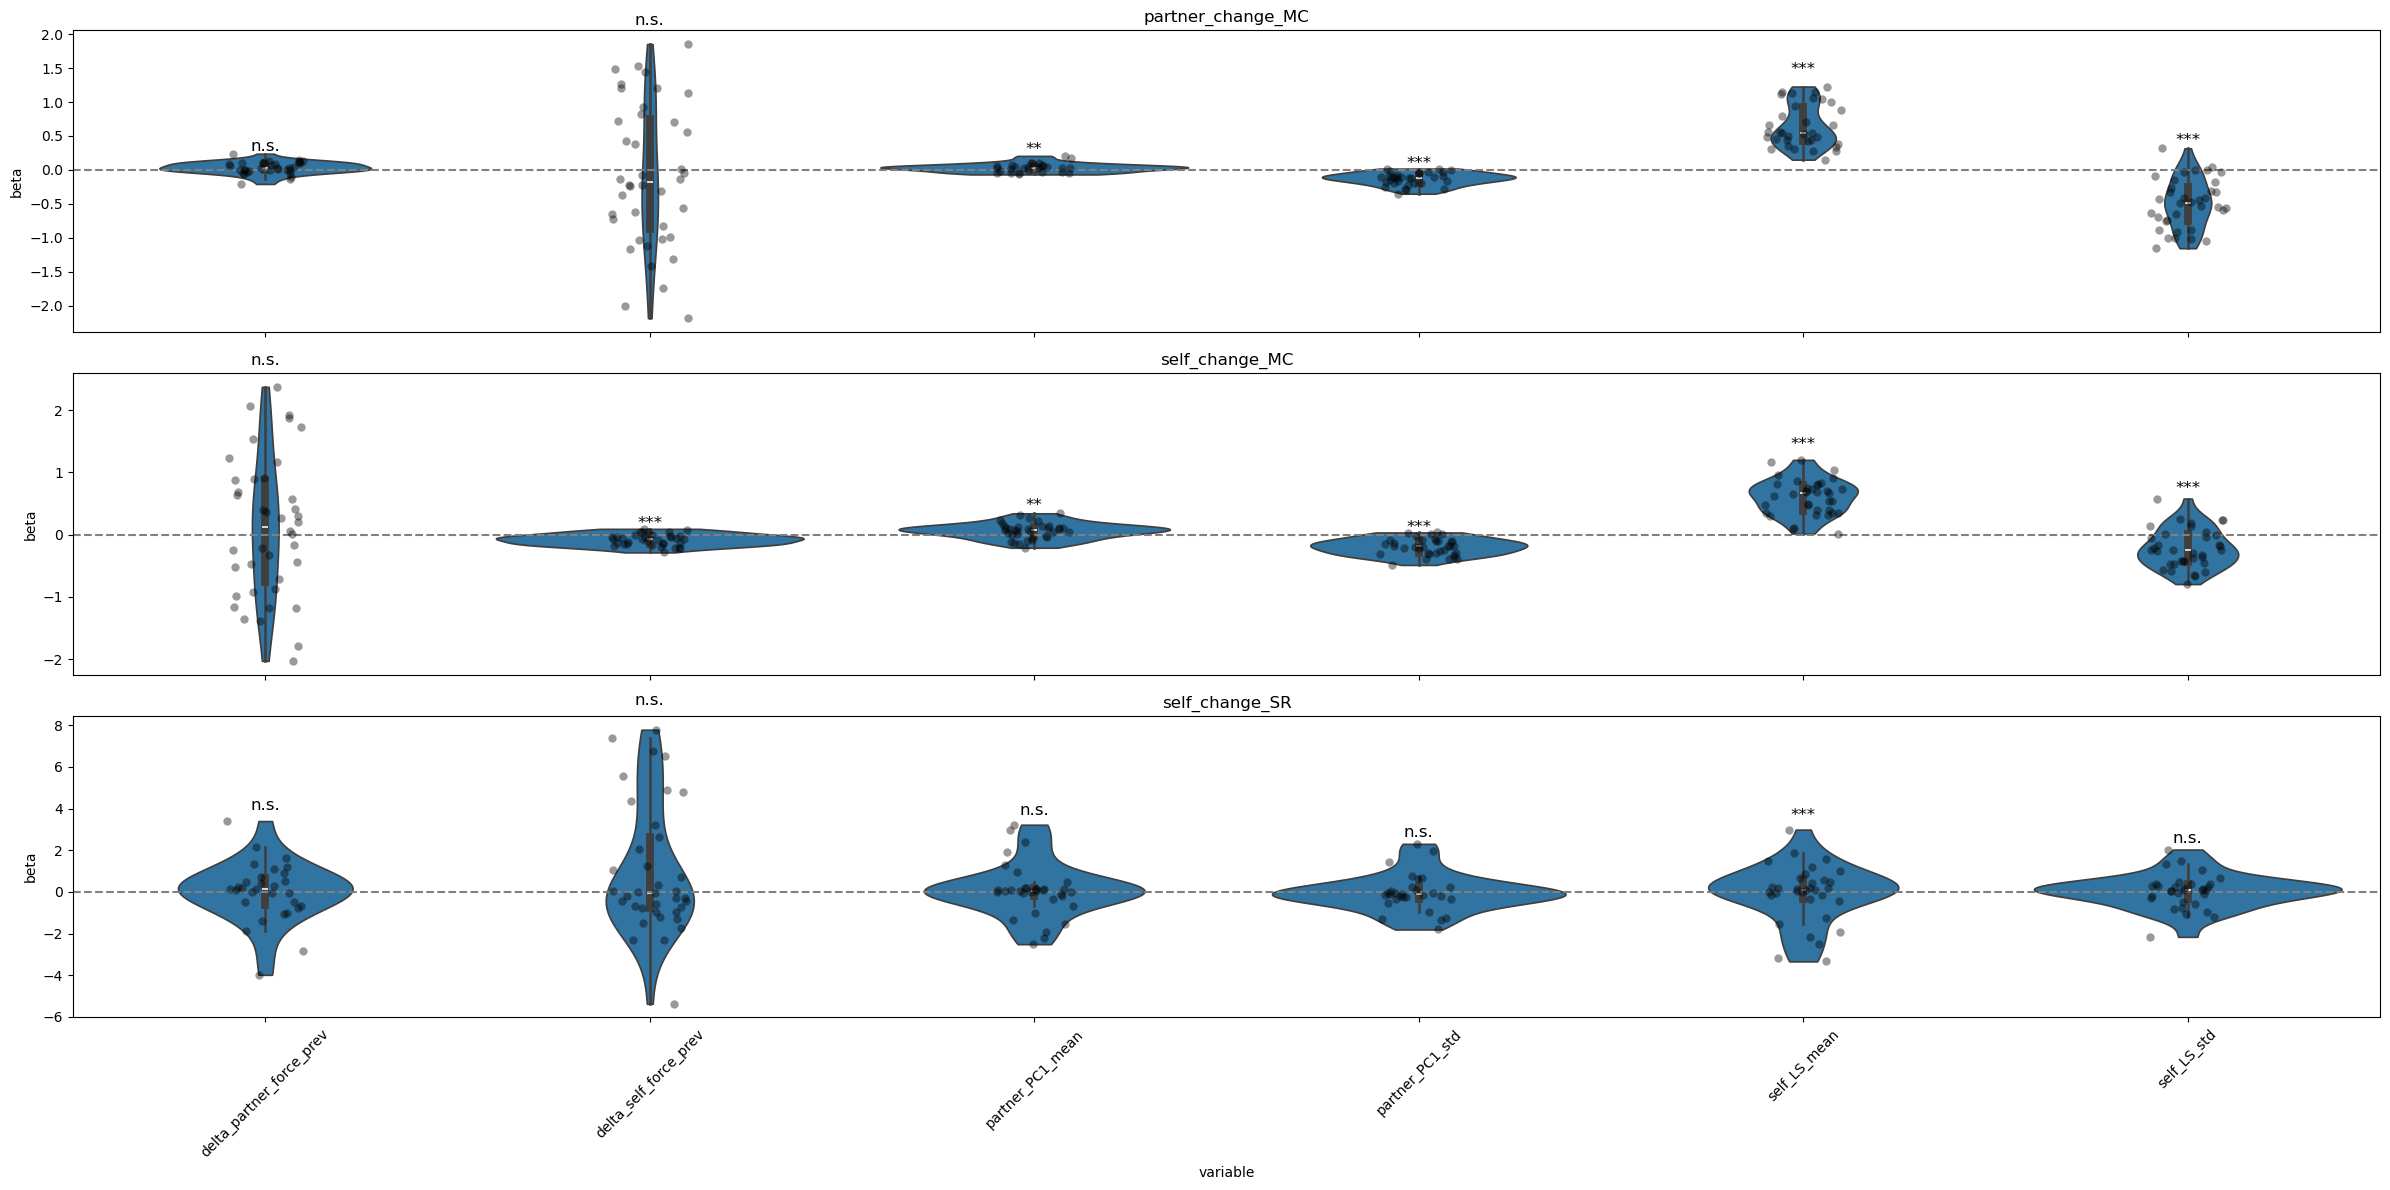

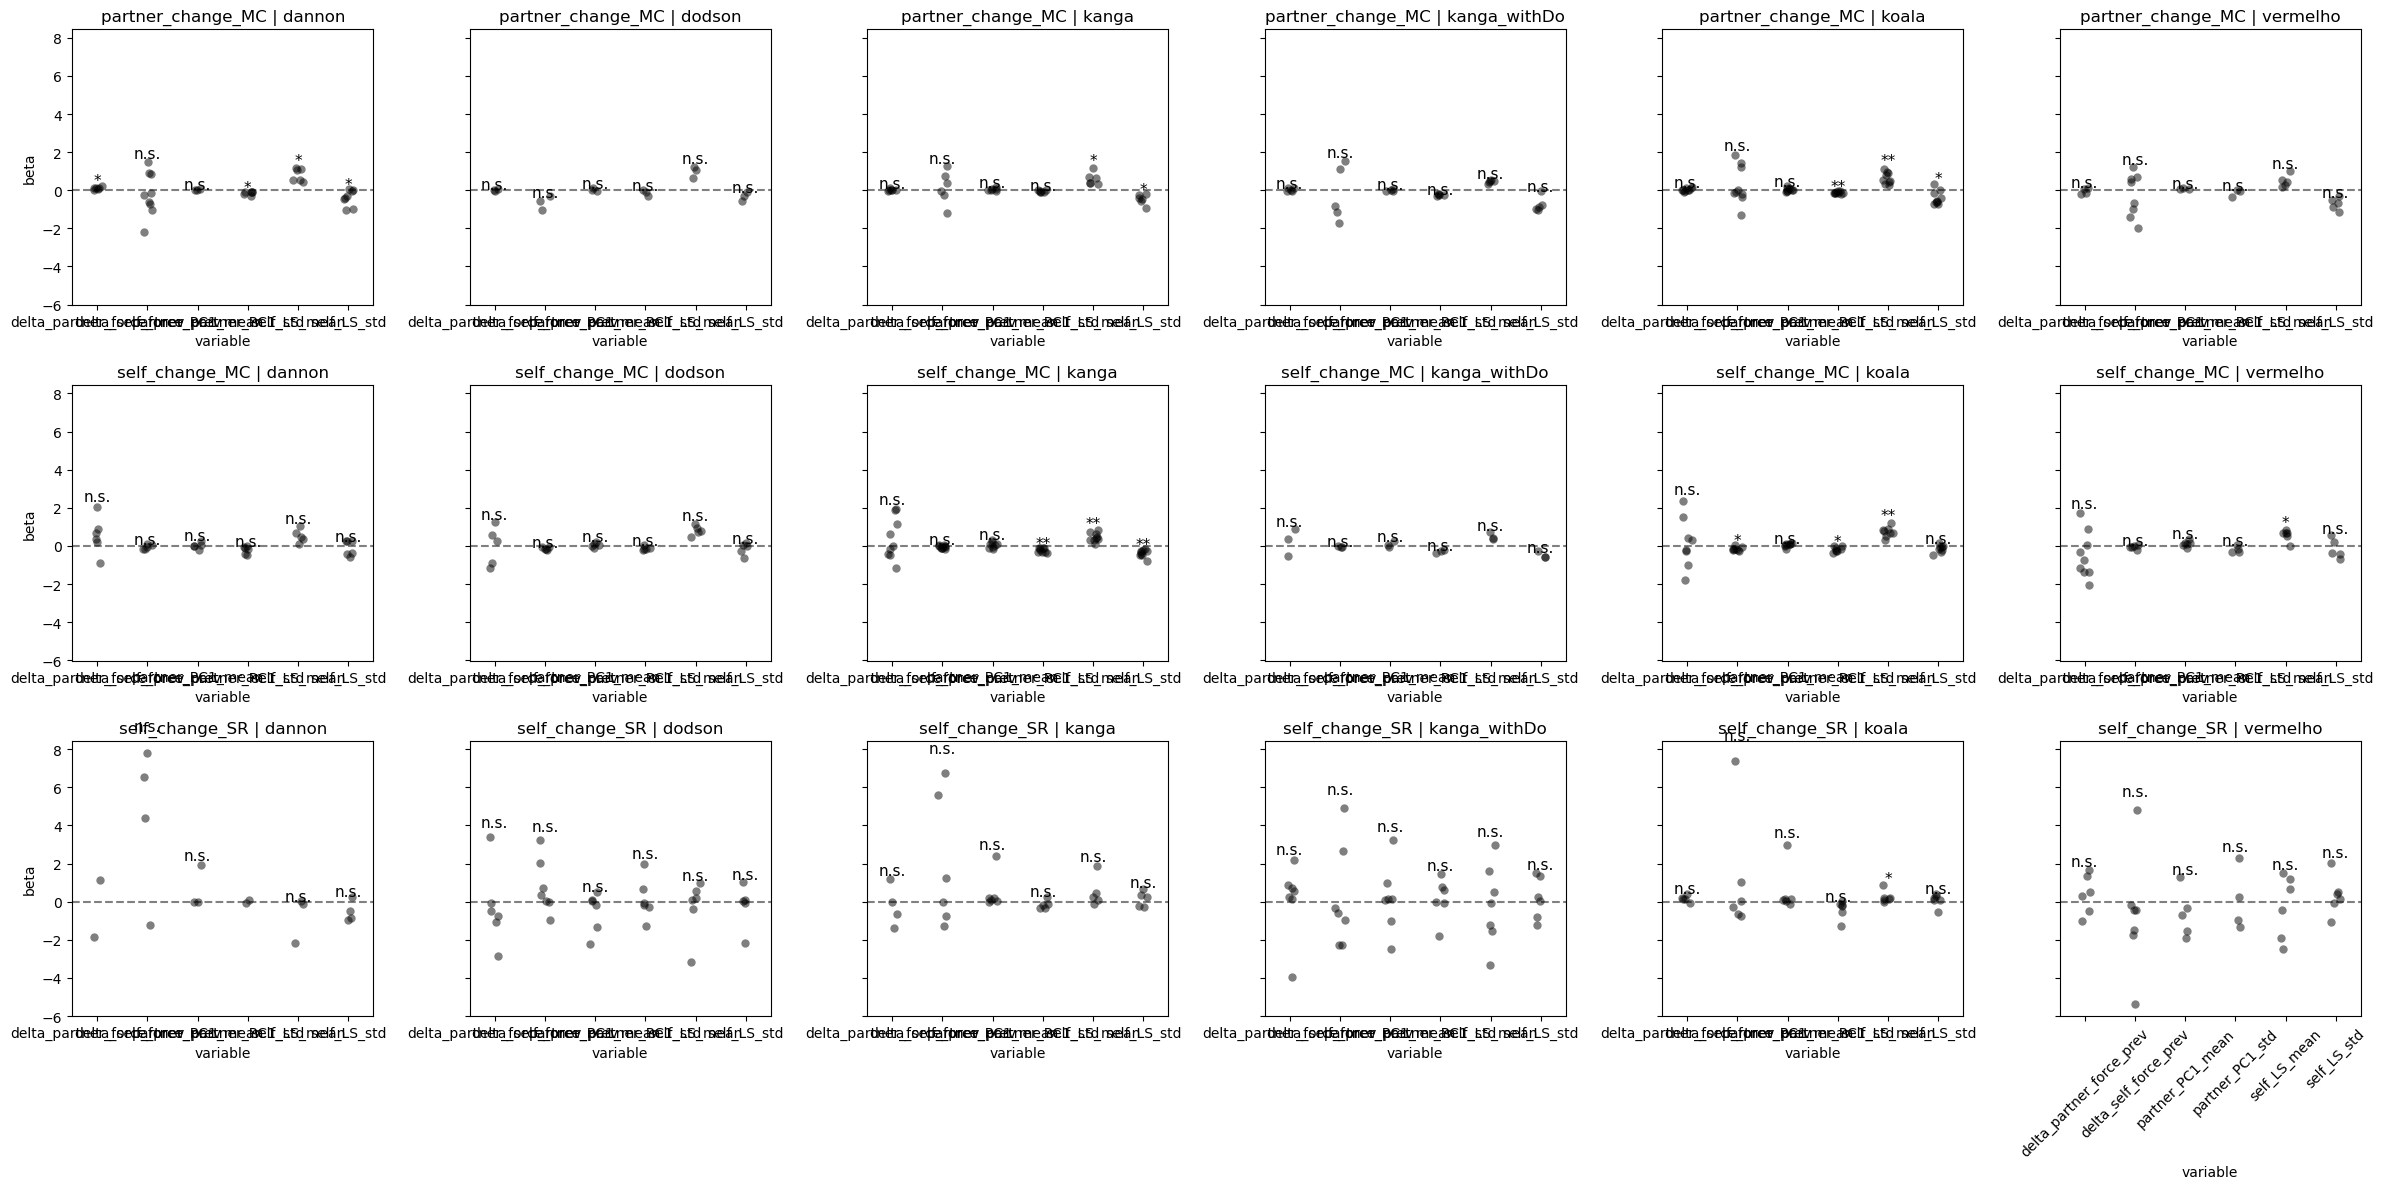

In [54]:
# do some plotting

# hddm, consider partner PC1 mean, partner PC1 std, self force delta prev, partner force delta prev,
# self LS mean and self LS std

if 1:
    
    import seaborn as sns
    import scipy.stats as st
    import statsmodels.formula.api as smf

    df = hddm_beta_summary_df.copy()
    df = df[df['variable'].str.startswith('v_')]
    df = df[df['variable']!='v_Intercept']
    df['variable'] = df['variable'].str.replace('v_','')

    force_types = sorted(df['forceContType'].unique())
    variables = sorted(df['variable'].unique())
    animals = sorted(df['self_animal'].unique())

    def remove_outliers(g):
        q1,q3 = g['beta_mean'].quantile(0.25), g['beta_mean'].quantile(0.75)
        iqr = q3-q1
        return g[(g['beta_mean']>=q1-1.5*iqr) & (g['beta_mean']<=q3+1.5*iqr)]

    df_clean = df.groupby(['forceContType','variable'],group_keys=False).apply(remove_outliers).reset_index(drop=True)

    # ======================================================
    # FIGURE 1 pooled animals (LMM)
    # ======================================================

    fig1,axes = plt.subplots(len(force_types),1,figsize=(4*len(variables),4*len(force_types)),sharex=True)
    if len(force_types)==1: axes=[axes]

    for i,force_type in enumerate(force_types):
        ax=axes[i]
        data=df_clean[df_clean['forceContType']==force_type]

        sns.violinplot(data=data,x='variable',y='beta_mean',cut=0,ax=ax)
        sns.stripplot(data=data,x='variable',y='beta_mean',color='black',size=6,alpha=0.4,ax=ax)
        ax.axhline(0,color='gray',linestyle='--')
        ax.set_title(force_type); ax.set_ylabel("beta")

        for j,var in enumerate(variables):
            sub=data[data['variable']==var].dropna()
            if len(sub)<5: continue
            try:
                sub=sub.rename(columns={'beta_mean':'y'})
                fit=smf.mixedlm("y ~ 1",sub,groups=sub["self_animal"]).fit(method='lbfgs',disp=False)
                p=fit.pvalues['Intercept']
            except: p=np.nan
            star='***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
            ax.text(j,sub['y'].max()*1.15,star,ha='center',fontsize=12)

    plt.xticks(rotation=45); plt.tight_layout(); plt.show()


    # ======================================================
    # FIGURE 2 separate animals
    # ======================================================

    fig2,axes = plt.subplots(len(force_types),len(animals),figsize=(4*len(animals),4*len(force_types)),sharey=True)
    if len(force_types)==1: axes=np.expand_dims(axes,axis=0)

    for i,force_type in enumerate(force_types):
        for j,animal in enumerate(animals):

            ax=axes[i,j]
            data=df_clean[(df_clean['forceContType']==force_type) & (df_clean['self_animal']==animal)]

            if len(data)==0: ax.axis('off'); continue

            # sns.violinplot(data=data,x='variable',y='beta_mean',inner='box',cut=0,ax=ax)
            sns.stripplot(data=data,x='variable',y='beta_mean',color='black',size=6,alpha=0.5,ax=ax)

            ax.axhline(0,color='gray',linestyle='--')
            ax.set_title(f"{force_type} | {animal}"); ax.set_ylabel("beta")

            for k,var in enumerate(variables):
                vals=data[data['variable']==var]['beta_mean'].dropna()
                if len(vals)<3: continue
                try: p=st.wilcoxon(vals)[1]
                except: p=np.nan
                star='***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
                ax.text(k,vals.max()*1.15,star,ha='center',fontsize=11)

    plt.xticks(rotation=45); plt.tight_layout(); plt.show()
    
    savefigs = 1
    if savefigs:
        figsavefolder = 'figures/figs_for_BasicBhvAna_singlecam_wholebodylabels_allsessions_basicEvents_PullStartToPull_continuousBhv_with_hddm_model/'
        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
        fig1.savefig(figsavefolder+"hddm_model_fitted_moreVar_allanimals.pdf")
        fig2.savefig(figsavefolder+"hddm_model_fitted_moreVar_eachanimal.pdf")
    


### hddm model consider more partner self delta force for v

In [44]:
# hddm, consider partner PC1 mean, partner PC1 std, self force delta prev, partner force delta with self,
# self LS mean and self LS std

if 0:
    
    with open('big_pull_df_all.pkl', 'rb') as f:
        big_pull_df_all = pickle.load(f)

    big_pull_df_all['delta_partner_force_withself'] = (big_pull_df_all['partner_force'] - \
                                                       big_pull_df_all['self_force']) /   \
                                                      (big_pull_df_all['partner_force'] + \
                                                       big_pull_df_all['self_force'])
    
    
    #
    # HDDM settings - the basic setting
    samples=250 # 2000
    burn=100
    thin=1

    # -----------------------------------------
    # summary dataframe container
    # -----------------------------------------
    summary_rows = []

    #
    # load each animal
    all_animals = np.unique(big_pull_df_all['self_animal']) 
    nanimals = np.shape(all_animals)[0]

    for ianimal in np.arange(0,nanimals,1):

        animal_tgt = all_animals[ianimal]

        big_pull_df_ianimal = big_pull_df_all[big_pull_df_all['self_animal']==animal_tgt]

        #
        # load each force condition
        all_forcetypes_ianimal = np.unique(big_pull_df_ianimal['forceContType'])
        nforcetypes = np.shape(all_forcetypes_ianimal)[0]

        for iforcetype in np.arange(0,nforcetypes,1):

            forcetype_ianimal = all_forcetypes_ianimal[iforcetype]

            big_pull_df_iani_iforce = big_pull_df_ianimal[big_pull_df_ianimal['forceContType']==forcetype_ianimal]

            #
            # load each dates
            all_dates_iani_iforce = np.unique(big_pull_df_iani_iforce['date'])
            ndates = np.shape(all_dates_iani_iforce)[0]

            for idate in np.arange(0,ndates,1):

                date_tgt_iani_iforce = all_dates_iani_iforce[idate]

                df_iani_iforce_idate = big_pull_df_iani_iforce[big_pull_df_iani_iforce['date']==date_tgt_iani_iforce]

                #
                # run hddm if it's not saved

                # try to load the data first
                try:
                    # dummy
                    
                    tgt_dir = 'hddm_model_result/'+animal_tgt+'/'+forcetype_ianimal+'/'+date_tgt_iani_iforce+'/'
                    #
                    with open(tgt_dir+'/hddm_model_fitted_moreVar2_traces.pkl', 'rb') as f:
                        hddm_model_fitted_moreVar2_traces = pickle.load(f)
                    #
                    with open(tgt_dir+'/hddm_model_fitted_moreVar2_stats.pkl', 'rb') as f:
                        hddm_model_fitted_moreVar2_stats = pickle.load(f)
                    #    
                    with open(tgt_dir+'/hddm_model_fitted_moreVar2_dic.pkl', 'rb') as f:
                        hddm_model_fitted_moreVar2_dic = pickle.load(f)

                    print('load hddm model_moreVar2 result for '+animal_tgt+' '+forcetype_ianimal+' '+date_tgt_iani_iforce)

                except:
                    print('run hddm model_moreVar2 fitting for '+animal_tgt+' '+forcetype_ianimal+' '+date_tgt_iani_iforce)

                    # try:
                    hddm_model_fitted = run_hddm_modeling_gazefilter_partnerPC1_partner_self_delta_force(df_iani_iforce_idate, 
                                                                      animal_tgt, samples, burn, thin)
                    #
                    hddm_model_fitted_moreVar2_traces = hddm_model_fitted.get_traces()
                    hddm_model_fitted_moreVar2_stats  = hddm_model_fitted.gen_stats()
                    hddm_model_fitted_moreVar2_dic = hddm_model_fitted.dic_info

                    # except:

                    #     hddm_model_fitted_moreVar2_traces = np.nan
                    #     hddm_model_fitted_moreVar2_stats  = np.nan
                    #     hddm_model_fitted_moreVar2_dic = np.nan

                    # save data
                    tgt_dir = 'hddm_model_result/'+animal_tgt+'/'+forcetype_ianimal+'/'+date_tgt_iani_iforce+'/'
                    if not os.path.exists(tgt_dir):
                        os.makedirs(tgt_dir)
                    #
                    #
                    with open(tgt_dir+'/hddm_model_fitted_moreVar2_traces.pkl', 'wb') as f:
                        pickle.dump(hddm_model_fitted_moreVar2_traces, f)
                    #
                    with open(tgt_dir+'/hddm_model_fitted_moreVar2_stats.pkl', 'wb') as f:
                        pickle.dump(hddm_model_fitted_moreVar2_stats, f)
                    #
                    with open(tgt_dir+'/hddm_model_fitted_moreVar2_dic.pkl', 'wb') as f:
                        pickle.dump(hddm_model_fitted_moreVar2_dic, f)



                # -------------------------------------------------
                # NEW PART: summarize betas
                # -------------------------------------------------
                try:

                    # variable names from traces
                    beta_vars = list(hddm_model_fitted_moreVar2_traces.columns)

                    for var in beta_vars:

                        beta_mean_trace = np.nanmean(hddm_model_fitted_moreVar2_traces[var])

                        if var in hddm_model_fitted_moreVar2_stats.index:

                            ci_low = hddm_model_fitted_moreVar2_stats.loc[var, '2.5q']
                            ci_high = hddm_model_fitted_moreVar2_stats.loc[var, '97.5q']

                            significant = (ci_low > 0) or (ci_high < 0)

                        else:
                            ci_low = np.nan
                            ci_high = np.nan
                            significant = False

                        summary_rows.append({
                            'self_animal': animal_tgt,
                            'date': date_tgt_iani_iforce,
                            'forceContType': forcetype_ianimal,
                            'variable': var,
                            'beta_mean': beta_mean_trace,
                            'ci_low': ci_low,
                            'ci_high': ci_high,
                            'significant': significant
                        })

                except:
                    pass


    # -----------------------------------------
    # final summary dataframe
    # -----------------------------------------

    hddm_beta_summary_df = pd.DataFrame(summary_rows)


In [45]:
# do some plotting

# hddm, consider partner PC1 mean, partner PC1 std, self force delta prev, partner force delta with self,
# self LS mean and self LS std
if 0:
    
    import seaborn as sns
    import scipy.stats as st
    import statsmodels.formula.api as smf

    df = hddm_beta_summary_df.copy()
    df = df[df['variable'].str.startswith('v_')]
    df = df[df['variable']!='v_Intercept']
    df['variable'] = df['variable'].str.replace('v_','')

    force_types = sorted(df['forceContType'].unique())
    variables = sorted(df['variable'].unique())
    animals = sorted(df['self_animal'].unique())

    def remove_outliers(g):
        q1,q3 = g['beta_mean'].quantile(0.25), g['beta_mean'].quantile(0.75)
        iqr = q3-q1
        return g[(g['beta_mean']>=q1-1.5*iqr) & (g['beta_mean']<=q3+1.5*iqr)]

    df_clean = df.groupby(['forceContType','variable'],group_keys=False).apply(remove_outliers).reset_index(drop=True)

    # ======================================================
    # FIGURE 1 pooled animals (LMM)
    # ======================================================

    fig1,axes = plt.subplots(len(force_types),1,figsize=(4*len(variables),4*len(force_types)),sharex=True)
    if len(force_types)==1: axes=[axes]

    for i,force_type in enumerate(force_types):
        ax=axes[i]
        data=df_clean[df_clean['forceContType']==force_type]

        sns.violinplot(data=data,x='variable',y='beta_mean',cut=0,ax=ax)
        sns.stripplot(data=data,x='variable',y='beta_mean',color='black',size=6,alpha=0.4,ax=ax)
        ax.axhline(0,color='gray',linestyle='--')
        ax.set_title(force_type); ax.set_ylabel("beta")

        for j,var in enumerate(variables):
            
            # try LMM
            if 0:
                sub=data[data['variable']==var].dropna()
                if len(sub)<5: continue
                try:
                    sub=sub.rename(columns={'beta_mean':'y'})
                    fit=smf.mixedlm("y ~ 1",sub,groups=sub["self_animal"]).fit(method='lbfgs',disp=False)
                    p=fit.pvalues['Intercept']
                except: p=np.nan
            
            # try simple wilcoxon
            if 1:
                vals=data[data['variable']==var]['beta_mean'].dropna()
                if len(vals)<3: continue
                try: p=st.wilcoxon(vals)[1]
                except: p=np.nan
                
            star='***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
            ax.text(j,sub['y'].max()*1.15,star,ha='center',fontsize=12)

    plt.xticks(rotation=45); plt.tight_layout(); plt.show()


    # ======================================================
    # FIGURE 2 separate animals
    # ======================================================

    fig2,axes = plt.subplots(len(force_types),len(animals),figsize=(4*len(animals),4*len(force_types)),sharey=True)
    if len(force_types)==1: axes=np.expand_dims(axes,axis=0)

    for i,force_type in enumerate(force_types):
        for j,animal in enumerate(animals):

            ax=axes[i,j]
            data=df_clean[(df_clean['forceContType']==force_type) & (df_clean['self_animal']==animal)]

            if len(data)==0: ax.axis('off'); continue

            # sns.violinplot(data=data,x='variable',y='beta_mean',inner='box',cut=0,ax=ax)
            sns.stripplot(data=data,x='variable',y='beta_mean',color='black',size=6,alpha=0.5,ax=ax)

            ax.axhline(0,color='gray',linestyle='--')
            ax.set_title(f"{force_type} | {animal}"); ax.set_ylabel("beta")

            for k,var in enumerate(variables):
                vals=data[data['variable']==var]['beta_mean'].dropna()
                if len(vals)<3: continue
                try: p=st.wilcoxon(vals)[1]
                except: p=np.nan
                star='***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
                ax.text(k,vals.max()*1.15,star,ha='center',fontsize=11)

    plt.xticks(rotation=45); plt.tight_layout(); plt.show()
    
    
    savefigs = 1
    if savefigs:
        figsavefolder = 'figures/figs_for_BasicBhvAna_singlecam_wholebodylabels_allsessions_basicEvents_PullStartToPull_continuousBhv_with_hddm_model/'
        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
        fig1.savefig(figsavefolder+"hddm_model_fitted_moreVar2_allanimals.pdf")
        fig2.savefig(figsavefolder+"hddm_model_fitted_moreVar2_eachanimal.pdf")

### hddm model consider partner self delta force for v, and self force delta prev for z

In [51]:
# hddm, consider partner PC1 mean, partner PC1 std, partner force delta with self,
# self LS mean and self LS std for v; and self force delta prev for z 

if 0:
    
    with open('big_pull_df_all.pkl', 'rb') as f:
        big_pull_df_all = pickle.load(f)

    big_pull_df_all['delta_partner_force_withself'] = (big_pull_df_all['partner_force'] - \
                                                       big_pull_df_all['self_force']) /   \
                                                      (big_pull_df_all['partner_force'] + \
                                                       big_pull_df_all['self_force'])
    
    big_pull_df_all['prev_trial_outcome']=big_pull_df_all['num_preceding_failpull']
    big_pull_df_all['prev_trial_outcome'] = (big_pull_df_all['num_preceding_failpull'] > 0).astype(int)
    
    
    #
    # HDDM settings - the basic setting
    samples=250 # 2000
    burn=100
    thin=1

    # -----------------------------------------
    # summary dataframe container
    # -----------------------------------------
    summary_rows = []

    #
    # load each animal
    all_animals = np.unique(big_pull_df_all['self_animal']) 
    nanimals = np.shape(all_animals)[0]

    for ianimal in np.arange(0,nanimals,1):

        animal_tgt = all_animals[ianimal]

        big_pull_df_ianimal = big_pull_df_all[big_pull_df_all['self_animal']==animal_tgt]

        #
        # load each force condition
        all_forcetypes_ianimal = np.unique(big_pull_df_ianimal['forceContType'])
        nforcetypes = np.shape(all_forcetypes_ianimal)[0]

        for iforcetype in np.arange(0,nforcetypes,1):

            forcetype_ianimal = all_forcetypes_ianimal[iforcetype]

            big_pull_df_iani_iforce = big_pull_df_ianimal[big_pull_df_ianimal['forceContType']==forcetype_ianimal]

            #
            # load each dates
            all_dates_iani_iforce = np.unique(big_pull_df_iani_iforce['date'])
            ndates = np.shape(all_dates_iani_iforce)[0]

            for idate in np.arange(0,ndates,1):

                date_tgt_iani_iforce = all_dates_iani_iforce[idate]

                df_iani_iforce_idate = big_pull_df_iani_iforce[big_pull_df_iani_iforce['date']==date_tgt_iani_iforce]

                #
                # run hddm if it's not saved

                # try to load the data first
                try:
                    # dummy
                    
                    tgt_dir = 'hddm_model_result/'+animal_tgt+'/'+forcetype_ianimal+'/'+date_tgt_iani_iforce+'/'
                    #
                    with open(tgt_dir+'/hddm_model_fitted_moreVar_withZ_traces.pkl', 'rb') as f:
                        hddm_model_fitted_moreVar_withZ_traces = pickle.load(f)
                    #
                    with open(tgt_dir+'/hddm_model_fitted_moreVar_withZ_stats.pkl', 'rb') as f:
                        hddm_model_fitted_moreVar_withZ_stats = pickle.load(f)
                    #    
                    with open(tgt_dir+'/hddm_model_fitted_moreVar_withZ_dic.pkl', 'rb') as f:
                        hddm_model_fitted_moreVar_withZ_dic = pickle.load(f)

                    print('load hddm model_moreVar_withZ result for '+animal_tgt+' '+forcetype_ianimal+' '+date_tgt_iani_iforce)

                except:
                    print('run hddm model_moreVar_withZ fitting for '+animal_tgt+' '+forcetype_ianimal+' '+date_tgt_iani_iforce)

                    # try:
                    hddm_model_fitted = run_hddm_modeling_gazefilter_partnerPC1_selfforceonZ(df_iani_iforce_idate, 
                                                                      animal_tgt, samples, burn, thin)
                    #
                    hddm_model_fitted_moreVar_withZ_traces = hddm_model_fitted.get_traces()
                    hddm_model_fitted_moreVar_withZ_stats  = hddm_model_fitted.gen_stats()
                    hddm_model_fitted_moreVar_withZ_dic = hddm_model_fitted.dic_info

                    # except:

                    #     hddm_model_fitted_moreVar_withZ_traces = np.nan
                    #     hddm_model_fitted_moreVar_withZ_stats  = np.nan
                    #     hddm_model_fitted_moreVar_withZ_dic = np.nan

                    # save data
                    tgt_dir = 'hddm_model_result/'+animal_tgt+'/'+forcetype_ianimal+'/'+date_tgt_iani_iforce+'/'
                    if not os.path.exists(tgt_dir):
                        os.makedirs(tgt_dir)
                    #
                    #
                    with open(tgt_dir+'/hddm_model_fitted_moreVar_withZ_traces.pkl', 'wb') as f:
                        pickle.dump(hddm_model_fitted_moreVar_withZ_traces, f)
                    #
                    with open(tgt_dir+'/hddm_model_fitted_moreVar_withZ_stats.pkl', 'wb') as f:
                        pickle.dump(hddm_model_fitted_moreVar_withZ_stats, f)
                    #
                    with open(tgt_dir+'/hddm_model_fitted_moreVar_withZ_dic.pkl', 'wb') as f:
                        pickle.dump(hddm_model_fitted_moreVar_withZ_dic, f)



                # -------------------------------------------------
                # NEW PART: summarize betas
                # -------------------------------------------------
                try:

                    # variable names from traces
                    beta_vars = list(hddm_model_fitted_moreVar_withZ_traces.columns)

                    for var in beta_vars:

                        beta_mean_trace = np.nanmean(hddm_model_fitted_moreVar_withZ_traces[var])

                        if var in hddm_model_fitted_moreVar_withZ_stats.index:

                            ci_low = hddm_model_fitted_moreVar_withZ_stats.loc[var, '2.5q']
                            ci_high = hddm_model_fitted_moreVar_withZ_stats.loc[var, '97.5q']

                            significant = (ci_low > 0) or (ci_high < 0)

                        else:
                            ci_low = np.nan
                            ci_high = np.nan
                            significant = False

                        summary_rows.append({
                            'self_animal': animal_tgt,
                            'date': date_tgt_iani_iforce,
                            'forceContType': forcetype_ianimal,
                            'variable': var,
                            'beta_mean': beta_mean_trace,
                            'ci_low': ci_low,
                            'ci_high': ci_high,
                            'significant': significant
                        })

                except:
                    pass


    # -----------------------------------------
    # final summary dataframe
    # -----------------------------------------

    hddm_beta_summary_df = pd.DataFrame(summary_rows)


In [52]:
# do some plotting

# hddm, consider partner PC1 mean, partner PC1 std, partner force delta with self,
# self LS mean and self LS std for v; and self force delta prev for z 

if 0:
    
    import seaborn as sns
    import scipy.stats as st
    import statsmodels.formula.api as smf

    df = hddm_beta_summary_df.copy()

    # keep both v_ and z_ parameters
    df = df[df['variable'].str.startswith(('v_','z_'))]
    df = df[~df['variable'].isin(['v_Intercept','z_Intercept'])]

    # remove prefix only for readability
    df['variable'] = df['variable'].str.replace('v_','v:')
    df['variable'] = df['variable'].str.replace('z_','z:')

    force_types = sorted(df['forceContType'].unique())
    variables = sorted(df['variable'].unique())
    animals = sorted(df['self_animal'].unique())

    def remove_outliers(g):
        q1,q3 = g['beta_mean'].quantile(0.25), g['beta_mean'].quantile(0.75)
        iqr = q3-q1
        return g[(g['beta_mean']>=q1-1.5*iqr) & (g['beta_mean']<=q3+1.5*iqr)]

    df_clean = df.groupby(['forceContType','variable'],group_keys=False).apply(remove_outliers).reset_index(drop=True)

    # ======================================================
    # FIGURE 1 pooled animals (LMM)
    # ======================================================

    fig1,axes = plt.subplots(len(force_types),1,figsize=(4*len(variables),4*len(force_types)),sharex=True)
    if len(force_types)==1: axes=[axes]

    for i,force_type in enumerate(force_types):
        ax=axes[i]
        data=df_clean[df_clean['forceContType']==force_type]

        sns.violinplot(data=data,x='variable',y='beta_mean',cut=0,ax=ax)
        sns.stripplot(data=data,x='variable',y='beta_mean',color='black',size=6,alpha=0.4,ax=ax)
        ax.axhline(0,color='gray',linestyle='--')
        ax.set_title(force_type); ax.set_ylabel("beta")

        for j,var in enumerate(variables):
            
            # try LMM
            if 1:
                sub=data[data['variable']==var].dropna()
                if len(sub)<5: continue
                try:
                    sub=sub.rename(columns={'beta_mean':'y'})
                    fit=smf.mixedlm("y ~ 1",sub,groups=sub["self_animal"]).fit(method='lbfgs',disp=False)
                    p=fit.pvalues['Intercept']
                except: p=np.nan
            
            # try simple wilcoxon
            if 0:
                vals=data[data['variable']==var]['beta_mean'].dropna()
                if len(vals)<3: continue
                try: p=st.wilcoxon(vals)[1]
                except: p=np.nan
                
            star='***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
            ax.text(j,sub['y'].max()*1.15,star,ha='center',fontsize=12)

    plt.xticks(rotation=45); plt.tight_layout(); plt.show()


    # ======================================================
    # FIGURE 2 separate animals
    # ======================================================

    fig2,axes = plt.subplots(len(force_types),len(animals),figsize=(4*len(animals),4*len(force_types)),sharey=True)
    if len(force_types)==1: axes=np.expand_dims(axes,axis=0)

    for i,force_type in enumerate(force_types):
        for j,animal in enumerate(animals):

            ax=axes[i,j]
            data=df_clean[(df_clean['forceContType']==force_type) & (df_clean['self_animal']==animal)]

            if len(data)==0: ax.axis('off'); continue

            sns.stripplot(data=data,x='variable',y='beta_mean',color='black',size=6,alpha=0.5,ax=ax)

            ax.axhline(0,color='gray',linestyle='--')
            ax.set_title(f"{force_type} | {animal}"); ax.set_ylabel("beta")

            for k,var in enumerate(variables):
                vals=data[data['variable']==var]['beta_mean'].dropna()
                if len(vals)<3: continue
                try: p=st.wilcoxon(vals)[1]
                except: p=np.nan
                star='***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
                ax.text(k,vals.max()*1.15,star,ha='center',fontsize=11)

    plt.xticks(rotation=45); plt.tight_layout(); plt.show()
    
    
    savefigs = 1
    if savefigs:
        figsavefolder = 'figures/figs_for_BasicBhvAna_singlecam_wholebodylabels_allsessions_basicEvents_PullStartToPull_continuousBhv_with_hddm_model/'
        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
        fig1.savefig(figsavefolder+"hddm_model_fitted_moreVar_withZ_allanimals.pdf")
        fig2.savefig(figsavefolder+"hddm_model_fitted_moreVar_withZ_eachanimal.pdf")

### dic comparison across the three models

Loaded 122 sessions
  self_animal      forceContType      date  Model1_base  Model2_moreVar  \
0      dannon  partner_change_MC  20240910          NaN      118.803607   
1      dannon  partner_change_MC  20240911   131.513884      128.516450   
2      dannon  partner_change_MC  20240916   306.815731      295.161832   
3      dannon  partner_change_MC  20240918   194.192029      331.220702   
4      dannon  partner_change_MC  20240919   144.688806      329.545340   

   Model2-2_moreVar2  Model3_moreVar+Z  
0         116.824541        121.304379  
1          62.552885        122.493225  
2         302.424723        328.905433  
3         196.727632        259.654786  
4         143.497191        145.573005  


/tmp/ipykernel_100/1406734338.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='model', y='DIC', cut=0,
/tmp/ipykernel_100/1406734338.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='model', y='DIC', cut=0,
/tmp/ipykernel_100/1406734338.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='model', y='DIC', cut=0,


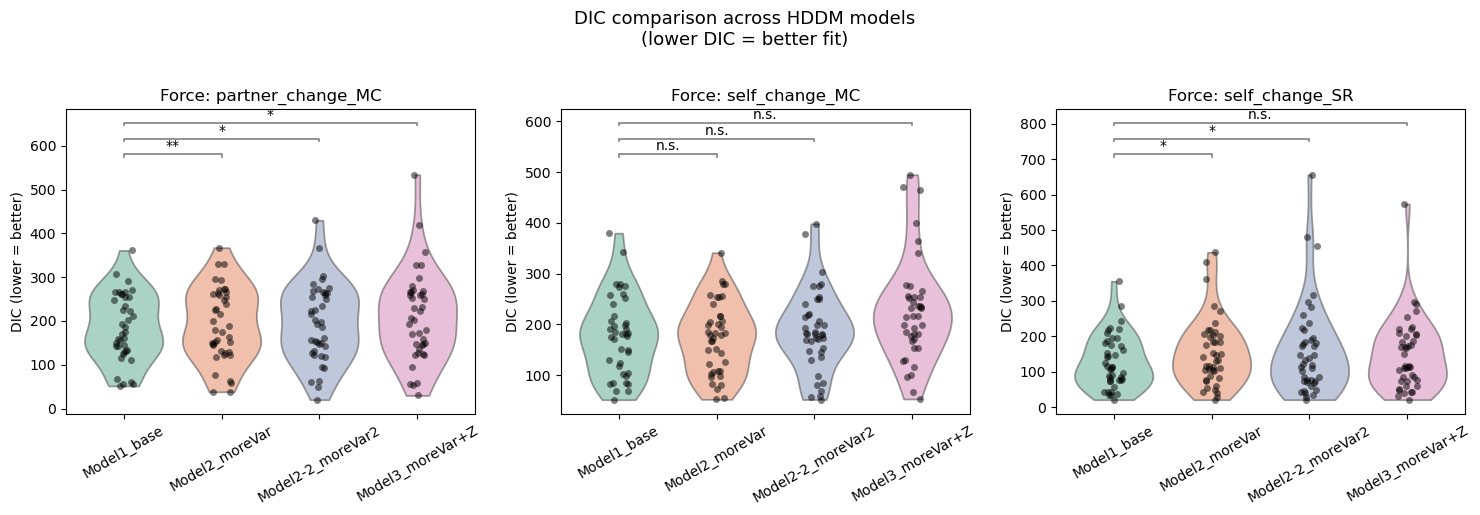


=== DIC Summary (mean ± SEM) ===
    forceContType             model   mean_DIC   sem_DIC  n
partner_change_MC       Model1_base 185.175178 12.405772 39
partner_change_MC Model2-2_moreVar2 194.901764 14.061593 40
partner_change_MC    Model2_moreVar 193.237025 13.291428 40
partner_change_MC  Model3_moreVar+Z 209.583745 16.253254 40
   self_change_MC       Model1_base 178.571205 12.343391 40
   self_change_MC Model2-2_moreVar2 187.811993 12.530946 40
   self_change_MC    Model2_moreVar 173.845904 11.159563 40
   self_change_MC  Model3_moreVar+Z 227.036609 16.202479 40
   self_change_SR       Model1_base 129.067404 11.581272 42
   self_change_SR Model2-2_moreVar2 160.998782 20.243156 42
   self_change_SR    Model2_moreVar 155.683613 14.830846 42
   self_change_SR  Model3_moreVar+Z 148.087090 15.625422 42

=== Best model (lowest mean DIC) per force type ===
  partner_change_MC     →  Model1_base  (mean DIC = 185.2 ± 12.4)
  self_change_MC        →  Model2_moreVar  (mean DIC = 173.8 ± 11.2

In [50]:
# ### DIC comparison across the three models
# Models:
#   Model 1 (base):        hddm_model_fitted_dic           → saved as 'hddm_model_fitted_dic.pkl'
#   Model 2 (moreVar):     hddm_model_fitted_moreVar_dic   → saved as 'hddm_model_fitted_moreVar_dic.pkl'
#   Model 3 (moreVar+Z):   hddm_model_fitted_moreVar_withZ_dic → saved as 'hddm_model_fitted_moreVar_withZ_dic.pkl'

# -------------------------------------------------------
# 1. Discover all session folders and load the three DICs
# -------------------------------------------------------

base_dir = 'hddm_model_result'

model_configs = {
    'Model1_base':      'hddm_model_fitted_dic.pkl',
    'Model2_moreVar':   'hddm_model_fitted_moreVar_dic.pkl',
    'Model2-2_moreVar2':   'hddm_model_fitted_moreVar2_dic.pkl',
    'Model3_moreVar+Z': 'hddm_model_fitted_moreVar_withZ_dic.pkl',
}

dic_rows = []

for animal in sorted(os.listdir(base_dir)):
    animal_dir = os.path.join(base_dir, animal)
    if not os.path.isdir(animal_dir):
        continue
    for force in sorted(os.listdir(animal_dir)):
        force_dir = os.path.join(animal_dir, force)
        if not os.path.isdir(force_dir):
            continue
        for date in sorted(os.listdir(force_dir)):
            date_dir = os.path.join(force_dir, date)
            if not os.path.isdir(date_dir):
                continue

            row = {'self_animal': animal, 'forceContType': force, 'date': date}
            all_loaded = True

            for model_name, fname in model_configs.items():
                fpath = os.path.join(date_dir, fname)
                try:
                    with open(fpath, 'rb') as f:
                        dic_info = pickle.load(f)
                    # dic_info is a dict with keys 'DIC' and 'pD'
                    row[model_name] = dic_info['DIC']
                except Exception as e:
                    print(f'  WARNING: could not load {fpath}: {e}')
                    row[model_name] = np.nan
                    all_loaded = False

            dic_rows.append(row)

dic_df = pd.DataFrame(dic_rows)
print(f'Loaded {len(dic_df)} sessions')
print(dic_df.head())

# -------------------------------------------------------
# 2. Melt into long format for plotting
# -------------------------------------------------------

model_cols = list(model_configs.keys())
dic_long = dic_df.melt(
    id_vars=['self_animal', 'forceContType', 'date'],
    value_vars=model_cols,
    var_name='model',
    value_name='DIC'
).dropna(subset=['DIC'])

# -------------------------------------------------------
# 3. Violin + strip plot of DIC per model, split by force type
# -------------------------------------------------------

force_types = sorted(dic_long['forceContType'].unique())
palette = sns.color_palette('Set2', len(model_cols))

fig, axes = plt.subplots(1, len(force_types),
                         figsize=(5 * len(force_types), 5),
                         sharey=False)
if len(force_types) == 1:
    axes = [axes]

for ax, force in zip(axes, force_types):
    data = dic_long[dic_long['forceContType'] == force]

    sns.violinplot(data=data, x='model', y='DIC', cut=0,
                   palette=palette, inner=None, alpha=0.6, ax=ax)
    sns.stripplot(data=data, x='model', y='DIC',
                  color='black', size=5, alpha=0.5, jitter=True, ax=ax)

    ax.set_title(f'Force: {force}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('DIC (lower = better)')
    ax.tick_params(axis='x', rotation=30)

    # --- pairwise Wilcoxon between every pair of models ---
    from itertools import combinations
    y_max = data['DIC'].max()
    y_range = data['DIC'].max() - data['DIC'].min()
    offsets = np.linspace(0.08, 0.22, 3)

    for offset, (m1, m2) in zip(offsets, combinations(model_cols, 2)):
        v1 = data[data['model'] == m1]['DIC'].dropna()
        v2 = data[data['model'] == m2]['DIC'].dropna()
        # paired if same sessions, else unpaired
        common = set(data[data['model']==m1]['date']) & set(data[data['model']==m2]['date'])
        if len(common) >= 3:
            try:
                paired_v1 = data[(data['model']==m1) & (data['date'].isin(common))].sort_values('date')['DIC']
                paired_v2 = data[(data['model']==m2) & (data['date'].isin(common))].sort_values('date')['DIC']
                _, p = st.wilcoxon(paired_v1, paired_v2)
            except:
                p = np.nan
        else:
            try:
                _, p = st.mannwhitneyu(v1, v2, alternative='two-sided')
            except:
                p = np.nan

        star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        x1, x2 = model_cols.index(m1), model_cols.index(m2)
        y_line = y_max + y_range * offset
        ax.plot([x1, x1, x2, x2], [y_line, y_line + y_range*0.01,
                                     y_line + y_range*0.01, y_line],
                lw=1.2, color='gray')
        ax.text((x1 + x2) / 2, y_line + y_range * 0.015, star,
                ha='center', va='bottom', fontsize=10)

plt.suptitle('DIC comparison across HDDM models\n(lower DIC = better fit)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('dic_comparison_violinplot.png', dpi=150, bbox_inches='tight')
plt.show()

# -------------------------------------------------------
# 4. Summary table: mean DIC ± SEM per model x force type
# -------------------------------------------------------

summary = dic_long.groupby(['forceContType', 'model'])['DIC'].agg(
    mean_DIC='mean', sem_DIC='sem', n='count'
).reset_index()

print('\n=== DIC Summary (mean ± SEM) ===')
print(summary.to_string(index=False))

# -------------------------------------------------------
# 5. Identify the best model per force type
# -------------------------------------------------------

print('\n=== Best model (lowest mean DIC) per force type ===')
for force in force_types:
    sub = summary[summary['forceContType'] == force]
    best_row = sub.loc[sub['mean_DIC'].idxmin()]
    print(f'  {force:20s}  →  {best_row["model"]}  '
          f'(mean DIC = {best_row["mean_DIC"]:.1f} ± {best_row["sem_DIC"]:.1f})')

# -------------------------------------------------------
# 6. Delta-DIC relative to Model1 (baseline)
# -------------------------------------------------------

print('\n=== ΔDIC relative to Model1_base (negative = improvement) ===')
dic_wide = dic_df[['self_animal','forceContType','date'] + model_cols].dropna()
for col in ['Model2_moreVar', 'Model3_moreVar+Z']:
    dic_wide[f'delta_{col}'] = dic_wide[col] - dic_wide['Model1_base']

delta_summary = dic_wide.groupby('forceContType')[
    ['delta_Model2_moreVar', 'delta_Model3_moreVar+Z']
].agg(['mean','sem'])
print(delta_summary.to_string())